<a href="https://colab.research.google.com/github/Harshith-32920/edav_density_and_contour_plots/blob/main/160123733191.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## **Density and contour plots**



Understand and visualize data distributions using:


* Density plots
* Contour plots


and interpret patterns, clusters, and relationships in data.




Reference
> https://jakevdp.github.io/PythonDataScienceHandbook/04.04-density-and-contour-plots.html




# Contour plot for probbility denisty

It is useful to display three-dimensional data in two dimensions using contours or color- coded regions. Three Matplotlib functions are used for this purpose. They are :

a) plt.contour for contour plots,

b) plt.contourf for filled contour plots,

c) plt.imshow for showing images.



In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

In [ ]:
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)
Z

array([[-0.83907153, -0.83470697, -0.8216586 , ...,  0.8956708 ,
         0.68617261,  0.41940746],
       [-0.83907153, -0.8275558 , -0.80744041, ...,  0.93467448,
         0.77467433,  0.55894214],
       [-0.83907153, -0.820263  , -0.79266951, ...,  0.98503397,
         0.88847607,  0.73757604],
       ...,
       [-0.83907153, -0.48696962, -0.02692065, ...,  0.98525345,
         0.79584263,  0.46799565],
       [-0.83907153, -0.47558005, -0.00130271, ...,  0.93488414,
         0.6993547 ,  0.37933079],
       [-0.83907153, -0.46410908,  0.02431613, ...,  0.89579384,
         0.65690314,  0.40107702]])

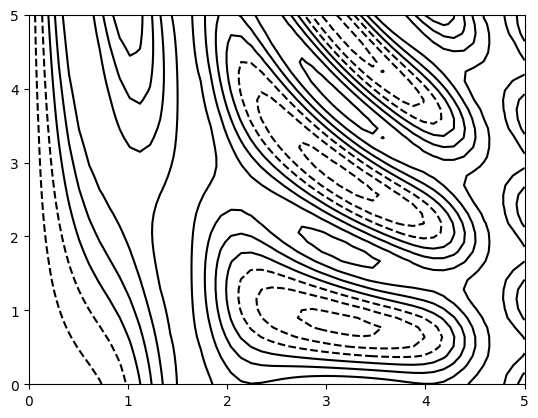

In [ ]:
plt.contour(X, Y, Z, colors='black');


### Dataset Selection: Iris Dataset

We will use the famous Iris dataset, which contains measurements for 150 iris flowers from three different species: *setosa*, *versicolor*, and *virginica*. It's a great dataset for illustrating these visualization techniques because it has multiple numerical variables and distinct categories.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the Iris dataset
iris = sns.load_dataset('iris')

# Display the first few rows of the dataset
print("First 5 rows of the Iris dataset:")
display(iris.head())

# Display basic information about the dataset
print("\nInformation about the Iris dataset:")
iris.info()

First 5 rows of the Iris dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Information about the Iris dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### Density Plots (KDE - Kernel Density Estimation)

Density plots are a powerful tool for visualizing the distribution of a single numerical variable. They provide a smoothed representation of the data's probability density function, making it easy to identify peaks, valleys, and the overall shape of the distribution. We'll use Seaborn's `kdeplot` for this.

Let's visualize the distribution of 'petal_length' for the entire dataset first, and then overlay density plots for each species to compare their distributions.

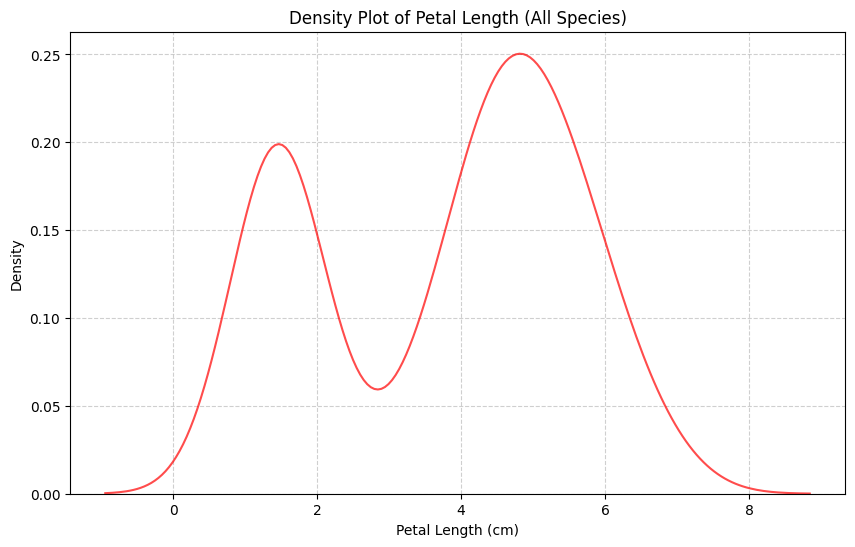

In [ ]:
# Density plot for 'petal_length' for the entire dataset
plt.figure(figsize=(10, 6))
sns.kdeplot(data=iris, x='petal_length', fill=False, color='red', alpha=0.7)
#labelling the plot
plt.title('Density Plot of Petal Length (All Species)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

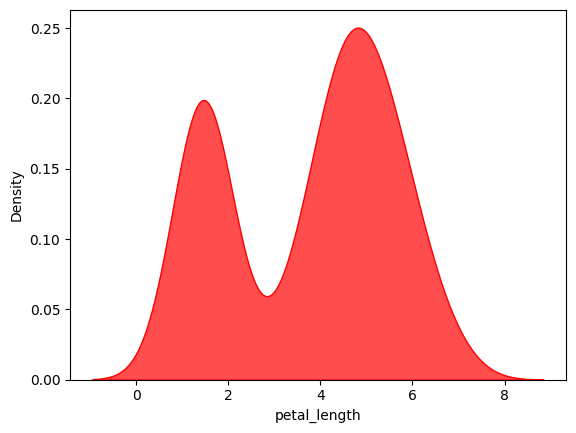

In [ ]:
sns.kdeplot(data=iris, x='petal_length', fill=True, color='red', alpha=0.7)
plt.show()

#### Overlayed Density Plots by Species

Now, let's create multiple density plots, overlaying them to compare the distribution of 'petal_length' among the three Iris species. This will highlight how 'petal_length' varies significantly across different species.

/tmp/ipykernel_1058/1166280160.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Species')


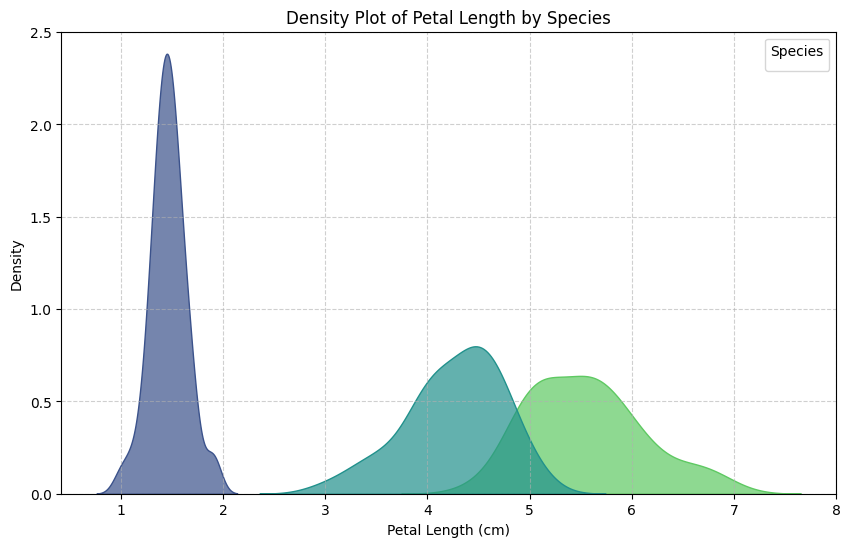

In [ ]:
# Overlayed density plots of 'petal_length' by 'species'
plt.figure(figsize=(10, 6))
sns.kdeplot(data=iris, x='petal_length', hue='species', fill=True, common_norm=False, palette='viridis', alpha=0.7)
plt.title('Density Plot of Petal Length by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Density')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

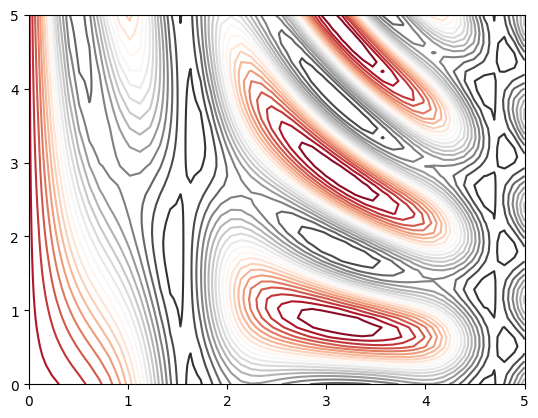

In [ ]:
plt.contour(X, Y, Z, 20, cmap='RdGy');

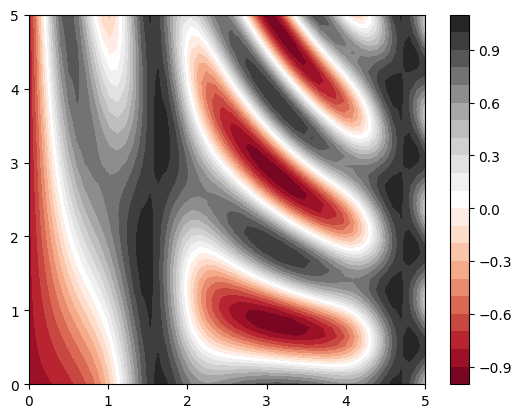

In [ ]:
plt.contourf(X, Y, Z, 20, cmap='RdGy')
plt.colorbar();

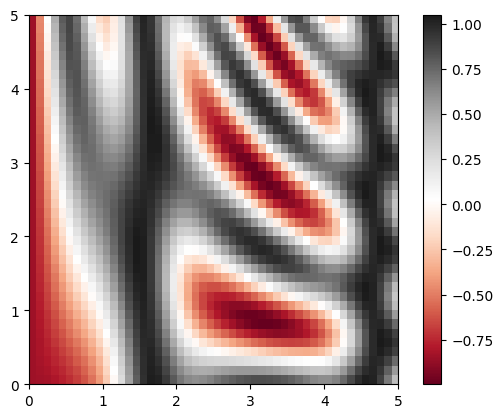

In [ ]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
# plt.axis(aspect='image');
# plt.axis('image');



### Contour Plots (2D Density Visualization)

Contour plots are excellent for visualizing the density of two numerical variables simultaneously. They can reveal relationships, clusters, and the distribution of data in a 2D space. We'll use `sepal_length` and `sepal_width` from the Iris dataset to demonstrate this.

In [1]:
# Select two numerical variables for the contour plot
x = iris['sepal_length']
y = iris['sepal_width']

# Create a 2D Kernel Density Estimate (KDE) to get density values
# This creates a smoothed estimate of the joint probability density function
# We'll use a grid to evaluate the KDE.

# Create a meshgrid for the contour plot
X_grid, Y_grid = np.meshgrid(np.linspace(x.min(), x.max(), 100),
                               np.linspace(y.min(), y.max(), 100))

# Evaluate the KDE on the grid (this requires a bit more advanced KDE estimation)
# For simplicity, let's use a scatter plot with density-based coloring or a 2D kdeplot from seaborn

plt.figure(figsize=(5, 4))

# Create a filled contour plot
sns.kdeplot(x=x, y=y, data=iris, fill=True, cmap='viridis', levels=15)

# Optionally, add unfllled contour lines on top for clearer boundaries
sns.kdeplot(x=x, y=y, data=iris, color='black', levels=15, linewidths=0.8)

plt.title('Contour Plot of Sepal Length vs. Sepal Width (Iris Dataset)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

NameError: name 'iris' is not defined